In [1]:
import torch
import torch.nn.functional as F
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm

from types import SimpleNamespace
from torch.utils.data import TensorDataset, DataLoader, random_split
from dataset_loader import NASDatasetFactory,load_nas201_api,arch_to_tensor
from model import VAE_dist,vae_accuracy_loss,FlowNet
from torch.utils.data import DataLoader
from train_flownas import pretrain_and_freeze_vae,run_training
from utils import build_accuracy_pairs, generate_archs,decoded_x_to_nas201_arch, query_nas201_accuracy,set_seed

c:\Users\tiber\Desktop\em\ALife\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensorflow is not installed.


## NAS201

In [2]:
DATASET_NAME = "NAS201"
api = load_nas201_api()

Dataset NAS201 già estratto.
Architetture NAS201 totali: 15625


In [3]:
#1 data loading
train_dataset,test_dataset,train_loader,test_loader = NASDatasetFactory.create(
    benchmark_name="NAS201",
    api=api,
    dataset_name="cifar10",     
    metric="test-accuracy",
    flatten=True,
    normalize_y=True,
)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 12500
Test size: 3125


### Analyzing 1 epoch of Training:

1. VAE TRAINING AND FREEZING ON DATASET

In [4]:
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
SEED = 42
# 2. Initialize VAE model
set_seed(SEED)
model = VAE_dist(
    LATENT_DIM=16
).to(DEVICE)
vae_optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)
# 3. Training VAE on the N samples
model.train()
model_acc = pretrain_and_freeze_vae(
    model_VAE=model,
    pretrain_loader=train_loader,
    loss_fn=vae_accuracy_loss,
    vae_epochs = 200,
    beta=0,
    lambda_acc=1.0,
    DEVICE=DEVICE,
    early_stop=False,
    freeze_after=False,
    lr=1e-3
)

Using device: cuda


VAE pretrain epoch 000 | loss=0.888761 | recon=0.757828 | kl=0.071044 | acc_loss=0.130933
VAE pretrain epoch 050 | loss=0.000381 | recon=0.000025 | kl=45.081492 | acc_loss=0.000356
VAE pretrain epoch 100 | loss=0.000202 | recon=0.000009 | kl=31.455104 | acc_loss=0.000193
VAE pretrain epoch 150 | loss=0.000139 | recon=0.000026 | kl=19.434203 | acc_loss=0.000113
VAE pretrained and frozen.


2. LATENT SPACE EMBEDDING EXTRACTION

In [5]:
N = 256
initial_loader = generate_archs(
    dataset=train_dataset,
    N=N
)
model.eval()
z_all = []
y_all = []

with torch.no_grad():
    for x, y in initial_loader:
        x = x.to(DEVICE).float()
        y = y.float().view(-1)
        mu, logvar = model.encode(x)

        z_all.append(mu.cpu())
        y_all.append(y.cpu())

z_all = torch.cat(z_all, dim=0)
y_all = torch.cat(y_all, dim=0)

print("z_all shape:", z_all.shape)
print("y_all shape:", y_all.shape)

z_all shape: torch.Size([256, 16])
y_all shape: torch.Size([256])


3. PAIRS GENERATION FOR FLOW MATCHING 

In [6]:
pairs_x, pairs_target= build_accuracy_pairs(
    X=z_all,
    y=y_all,
    K=50,
    min_delta_acc=0.01,
    seed=SEED
)
print("numero coppie:", len(pairs_x))

Number of pairs: 227
numero coppie: 227


4. FLOW TRAINING 

In [7]:
pairs_dataset = TensorDataset(pairs_x, pairs_target)
pairs_loader = DataLoader(
    pairs_dataset,
    batch_size=64,
    shuffle=True
)
set_seed(SEED)
flow = FlowNet(dim=16).to(DEVICE)
flow_optimizer = torch.optim.Adam(
    flow.parameters(),
    lr=1e-3
)
flow_epochs = 100
flow.train()

for epoch in range(flow_epochs):
    total_flow_loss = 0.0
    for z_start, direction_target in pairs_loader:
        z_start = z_start.to(DEVICE).float()
        direction_target = direction_target.to(DEVICE).float()

        pred_direction = flow(z_start)
        loss = F.mse_loss(pred_direction, direction_target)

        flow_optimizer.zero_grad()
        loss.backward()
        flow_optimizer.step()
        total_flow_loss += loss.item()
    if epoch % 40 == 0:
        print(
            f"Flow epoch {epoch:03d} | "
            f"loss={total_flow_loss:.6f}"
        )

Flow epoch 000 | loss=37.603634
Flow epoch 040 | loss=18.425560
Flow epoch 080 | loss=13.451864


5. GENERATING NEW ARCHITECTURES FROM FLOW DIRECTION 

In [8]:
flow.eval()
alpha = 0.5

with torch.no_grad():
    z_start = z_all.to(DEVICE).float()
    direction = flow(z_start)
    z_new = z_start + alpha * direction

print("z_new shape:", z_new.shape)

z_new shape: torch.Size([256, 16])


6. DECODING ARCHITECTURES 

In [9]:
model.eval()

with torch.no_grad():

    recon_logits_new, recon_probs_new = model.decode(
        z_new.to(DEVICE).float()
    )
    recon_probs_new = recon_probs_new.detach().cpu()

    new_archs = []
    new_accs = []
    new_infos = []

    for i in range(recon_probs_new.shape[0]):
        x_decoded = recon_probs_new[i]
        x_decoded = x_decoded.permute(2, 0, 1)  
        x_decoded = x_decoded.reshape(-1)     

        arch_str = decoded_x_to_nas201_arch(
            x_decoded
        )
        acc, info = query_nas201_accuracy(
            api=api,
            arch_str=arch_str,
            dataset_name="cifar10",
            hp="200",
            metric="test-accuracy"
        )

        if acc is None:
            continue

        acc = float(acc) / 100.0

        new_archs.append(arch_str)
        new_accs.append(acc)
        new_infos.append(info)

#### comparing accuracies

In [10]:
new_accs_array = np.array(
    [a for a in new_accs if a is not None],
    dtype=np.float32
)
print("Numero accuracy valide generate:", len(new_accs_array))
y_initial = y_all.detach().cpu().numpy().reshape(-1).astype(np.float32)

Numero accuracy valide generate: 256


In [11]:
import matplotlib.ticker as ticker
from scipy.stats import norm
def compare_accuracy_distributions(y_all, new_accs, title="NAS201 Accuracy: Initial vs Generated",path = None):
    if isinstance(y_all, torch.Tensor):
        y_init = y_all.detach().cpu().numpy().reshape(-1).astype(np.float32)
    else:
        y_init = np.array(y_all, dtype=np.float32).reshape(-1)

    y_gen = np.array([a for a in new_accs if a is not None], dtype=np.float32)

    if len(y_gen) == 0:
        raise ValueError("new_accs contiene solo valori None.")

    if y_init.max() <= 1.5:
        y_init = y_init * 100.0
    if y_gen.max() <= 1.5:
        y_gen = y_gen * 100.0

    mu_i,  std_i,  var_i  = y_init.mean(), y_init.std(),  y_init.var()
    mu_g,  std_g,  var_g  = y_gen.mean(),  y_gen.std(),   y_gen.var()

    print(f"INITIAL    — n={len(y_init):4d}  mean={mu_i:.3f}  var={var_i:.3f}  std={std_i:.3f}  min={y_init.min():.3f}  max={y_init.max():.3f}")
    print(f"GENERATED  — n={len(y_gen):4d}  mean={mu_g:.3f}  var={var_g:.3f}  std={std_g:.3f}  min={y_gen.min():.3f}  max={y_gen.max():.3f}")
    print(f"Δ mean = {mu_g - mu_i:+.3f}")

    margin = max(std_i, std_g) * 4.0
    xs     = np.linspace(min(mu_i, mu_g) - margin, max(mu_i, mu_g) + margin, 800)
    pdf_i  = norm.pdf(xs, mu_i, std_i)
    pdf_g  = norm.pdf(xs, mu_g, std_g)

    C_INIT, C_GEN, BG = "#4A90D9", "#C0503A", "#F7F7F5"

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_edgecolor("#CCCCCC")
    ax.spines["bottom"].set_edgecolor("#CCCCCC")

    ax.fill_between(xs, pdf_i, alpha=0.18, color=C_INIT)
    ax.fill_between(xs, pdf_g, alpha=0.18, color=C_GEN)
    ax.plot(xs, pdf_i, color=C_INIT, linewidth=2.2,
            label=f"Initial   (μ={mu_i:.2f},  σ²={var_i:.2f})")
    ax.plot(xs, pdf_g, color=C_GEN,  linewidth=2.2,
            label=f"Generated (μ={mu_g:.2f},  σ²={var_g:.2f})")

    ax.axvline(mu_i, color=C_INIT, linewidth=1.3, linestyle="--", alpha=0.9)
    ax.axvline(mu_g, color=C_GEN,  linewidth=1.3, linestyle="--", alpha=0.9)

    ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.6, linestyle="-", zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("Accuracy (%)", fontsize=11, labelpad=8, color="#444444")
    ax.set_ylabel("Density",      fontsize=11, labelpad=8, color="#444444")
    ax.tick_params(colors="#666666", labelsize=9.5)
    ax.set_xlim(xs[0], xs[-1])
    ax.set_ylim(bottom=0, top=max(pdf_i.max(), pdf_g.max()) * 1.18)

    ax.legend(fontsize=10, framealpha=0.85, edgecolor="#CCCCCC",
              loc="upper left", handlelength=1.8)

    fig.suptitle(title, fontsize=13, fontweight="bold", y=0.97, color="#2C2C2A")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if path is not None:
        plt.savefig(path, dpi=160, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    plt.show()

INITIAL    — n= 256  mean=86.899  var=145.350  std=12.056  min=10.000  max=94.063
GENERATED  — n= 256  mean=87.881  var=99.753  std=9.988  min=10.000  max=94.300
Δ mean = +0.982


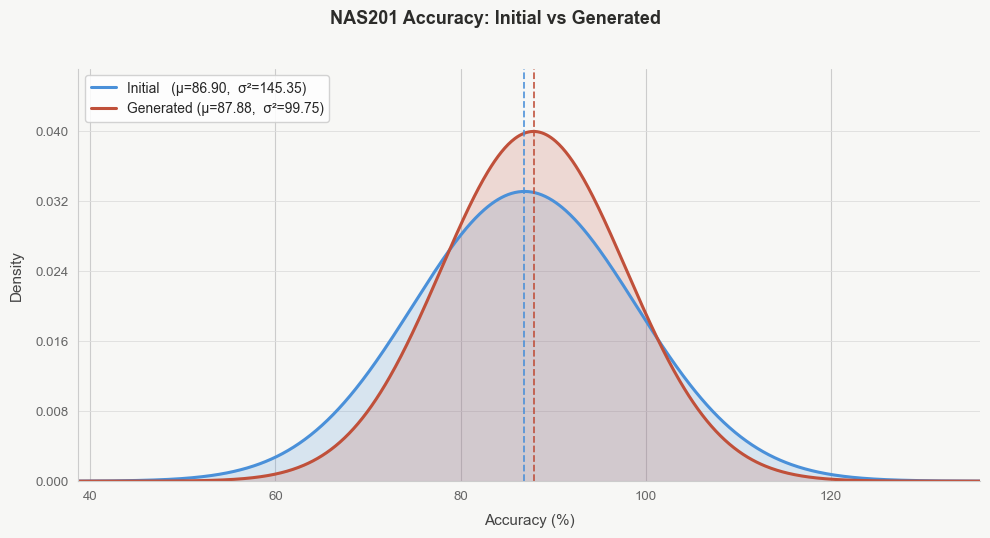

In [12]:
compare_accuracy_distributions(y_all, new_accs)

### training loop 

In [13]:
def plot_history_gaussians(
    history,
    title="NAS201 Accuracy distributions across outer epochs",
    save_path=None,
    max_gaussians=5
):
    epochs = np.array(history["epoch"])
    means = np.array(history["mean_acc"], dtype=np.float32)
    stds = np.array(history["std_acc"], dtype=np.float32)
    selected_idx = np.arange(len(means))

    epochs_plot = epochs[selected_idx]
    means_plot = means[selected_idx]
    stds_plot = stds[selected_idx]

    means_plot = means_plot * 100.0
    stds_plot = stds_plot * 100.0
    stds_plot = np.maximum(stds_plot, 1e-6)

    x_min = np.min(means_plot - 4 * stds_plot)
    x_max = np.max(means_plot + 4 * stds_plot)
    xs = np.linspace(x_min, x_max, 1000)

    BG = "#F7F7F5"

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_edgecolor("#CCCCCC")
    ax.spines["bottom"].set_edgecolor("#CCCCCC")

    colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(means_plot)))

    max_pdf = 0.0

    for epoch, mu, std, color in zip(epochs_plot, means_plot, stds_plot, colors):
        pdf = norm.pdf(xs, mu, std)
        max_pdf = max(max_pdf, pdf.max())
        ax.fill_between(xs, pdf, alpha=0.10, color=color)
        ax.plot(
            xs,
            pdf,
            color=color,
            linewidth=2.0,
            label=f"Epoch {epoch + 1} (μ={mu:.2f}, σ={std:.2f})"
        )
        ax.axvline(
            mu,
            color=color,
            linewidth=1.1,
            linestyle="--",
            alpha=0.75
        )

    ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.6, linestyle="-", zorder=0)
    ax.set_axisbelow(True)

    ax.set_xlabel("Accuracy (%)", fontsize=11, labelpad=8, color="#444444")
    ax.set_ylabel("Density", fontsize=11, labelpad=8, color="#444444")
    ax.tick_params(colors="#666666", labelsize=9.5)

    ax.set_xlim(xs[0], xs[-1])
    ax.set_ylim(bottom=0, top=max_pdf * 1.18)

    fig.suptitle(
        title,
        fontsize=13,
        fontweight="bold",
        y=0.97,
        color="#2C2C2A"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=160,
            bbox_inches="tight",
            facecolor=fig.get_facecolor()
        )

    plt.show()

In [14]:
args = SimpleNamespace(
    outer_epochs=10,
    N=256,
    latent_dim=16,
    batch_size=64,

    vae_epochs=200,
    pretrain_vae_epochs=300,
    pretrain_batch_size=64,
    pretrain_fraction=0.2,

    flow_epochs=200,
    alpha=0.5,

    beta=0.0,
    lambda_acc=1.0,

    use_top_mutations=False,
    elite_fraction=0.1,
    mutation_fraction=0.2,
    mutation_k=1,
    benchmark_name = "nas201",
    dataset_name="cifar100",
    nas_hp="200",
    nas_metric="test-accuracy",
    train_dataset = train_dataset,
    test_dataset = test_dataset,

    seed=SEED,
    device=DEVICE,
)


In [15]:
history, model_VAE, flow, test_dataset, api = run_training(args)

Dataset NAS201 già estratto.
Architetture NAS201 totali: 15625
Dataset available

 PRETRAIN VAE
VAE pretrain epoch 000 | loss=1.245526 | recon=0.980184 | kl=0.056048 | acc_loss=0.265341
VAE pretrain epoch 050 | loss=0.001676 | recon=0.000237 | kl=43.595580 | acc_loss=0.001439
VAE pretrain epoch 100 | loss=0.000940 | recon=0.000176 | kl=33.034057 | acc_loss=0.000764
Early stopping: patience reached at epoch 107, best_loss=0.000643
VAE pretrained and frozen.

 OUTER EPOCH 1/10 ==========
z_all shape: torch.Size([256, 16])
y_all shape: torch.Size([256])
Number of pairs: 225
pairs_x shape: torch.Size([225, 16])
pairs_target shape: torch.Size([225, 16])
z_new shape: torch.Size([256, 16])

Generated NAS201 architectures from FLOW:
valid archs = 256 / 256
mean acc    = 0.6349
std acc     = 0.0940
min acc     = 0.0100
max acc     = 0.7275

Next population:
use_top_mutations = False
population size   = 263
unique archs      = 263
duplicates        = 0
mean acc          = 0.6598
max acc         

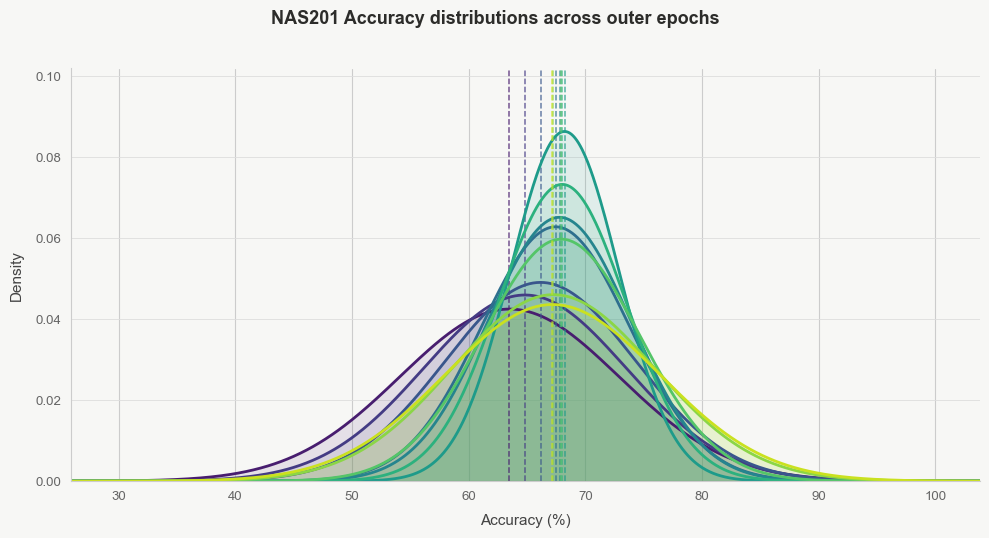

In [16]:
plot_history_gaussians(
    history,
    title="NAS201 Accuracy distributions across outer epochs",
    save_path=None,
    max_gaussians=5
)

## NAS301

### loading data

In [17]:
import pandas as pd

def load_csv_as_dataset(csv_path):
    df = pd.read_csv(csv_path)
    feature_cols = [col for col in df.columns if col.startswith("x_")]

    feature_cols = sorted(
        feature_cols,
        key=lambda c: int(c.split("_")[1])
    )

    X = df[feature_cols].values
    Y = df["accuracy"].values

    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)

    dataset = TensorDataset(X, Y)

    print("CSV caricato:", csv_path)
    print("Numero esempi:", len(dataset))
    return X, Y, dataset

X, Y, dataset_301 = load_csv_as_dataset(
    "nas301/nas301_dataset.csv")

CSV caricato: nas301/nas301_dataset.csv
Numero esempi: 50000


In [18]:
train_size = int(0.8 * len(dataset_301))
test_size = len(dataset_301) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, test_dataset = random_split(
    dataset_301,
    [train_size, test_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 40000
Test size: 10000


### training

In [ ]:
args = SimpleNamespace(
    benchmark_name="NAS301",
    n_samples=1000,          # piccolo per test veloce
    performance_model=None,  # lo carica la factory se return_model=True
    outer_epochs=20,
    N=1024,
    latent_dim=32,
    batch_size=64,

    vae_epochs=5,
    pretrain_vae_epochs=200,
    pretrain_batch_size=64,
    pretrain_fraction=0.5,

    flow_epochs=5,
    alpha=0.5,

    beta=0.0,
    lambda_acc=1.0,

    use_top_mutations=False,
    elite_fraction=0.2,
    mutation_fraction=0.2,
    mutation_k=1,

    benchmark_mane = "nas301",
    dataset_name="cifar10",
    nas_hp=None,
    nas_metric="surrogate_accuracy",

    train_dataset=train_dataset,
    test_dataset=test_dataset,
    pos_weight_value = 5,

    seed=42,
    device="cuda",
)

history, model_VAE, flow, test_dataset, api_or_model = run_training(args)

Pesi NAS-Bench-301 trovati localmente.
[09:28:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

[09:28:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en

c:\Users\tiber\Desktop\em\ALife\Deep-Learning-Project\dataset_loader.py:267: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
Exception ignored in: <function DMatrix.__del__ at 0x000001CFADF8A520>
Traceback (most recent call last):
  File "c:\Users\tiber\Desktop\em\ALife\venv\Lib\site-packages\xgboost\core.py", line 797, in __del__
    _check_call(_LIB.XGDMatrixFree(self.handle))
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt: 


In [ ]:
from types import SimpleNamespace

args = SimpleNamespace(
    benchmark_name="NAS301",

    n_samples=1000,
    performance_model=None,

    outer_epochs=20,
    N=1024,
    latent_dim=32,
    batch_size=64,

    vae_epochs=5,
    pretrain_vae_epochs=200,
    pretrain_batch_size=64,
    pretrain_fraction=0.5,

    flow_epochs=5,
    alpha=0.5,

    beta=0.0,
    lambda_acc=1.0,

    use_top_mutations=False,
    elite_fraction=0.2,
    mutation_fraction=0.2,
    mutation_k=1,

    benchmark_mane="nas301",
    dataset_name="cifar10",
    nas_hp=None,
    nas_metric="surrogate_accuracy",

    train_dataset=train_dataset,
    test_dataset=test_dataset,

    pos_weight_value=5,
    min_delta = 0.001
    seed=42,
    device="cuda",
)

In [ ]:
from nas301_flow_vs_random_20_runs import run_flow_vs_random_experiment
results_df, samples_df, summary_df = run_flow_vs_random_experiment(
    base_args=args,
    run_training_fn=run_training,
    n_runs=20,
    max_test_samples=None,
    initial_seed=42,
    output_dir="results_flow_vs_random"
)